# Battery heat generation and coolant flow sizing

How much heat does a battery pack make, and how much coolant does it need to carry it away?
Everything here is a first-principles estimate with illustrative cell values, not data from any product.

Steps: heat per cell → heat per pack → coolant flow → temperature rise with no cooling.

## 1. Heat from one cell

$$Q_{cell} = I^2 R_0(T) \; - \; I\,T\,\frac{dU}{dT}$$

The first term is ohmic heat. The second is the reversible (entropic) heat, positive on discharge when $dU/dT<0$.
The internal resistance rises as the cell gets colder:

$$R_0(T) = R_{25}\,\exp\!\left[\frac{E}{R}\left(\frac{1}{T}-\frac{1}{298.15}\right)\right]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

cap_Ah   = 50.0        # cell capacity
R25      = 1.0e-3      # ohm, resistance at 25 C (illustrative)
E_over_R = 2000.0      # K, temperature sensitivity of resistance (illustrative)
dUdT     = -0.1e-3     # V/K, entropic coefficient (illustrative, chemistry and SOC dependent)

def R0(T_C):
    T = T_C + 273.15
    return R25 * np.exp(E_over_R * (1/T - 1/298.15))

def q_cell(c_rate, T_C):
    I = c_rate * cap_Ah
    T = T_C + 273.15
    ohmic = I**2 * R0(T_C)
    rev   = -I * T * dUdT
    return ohmic, rev

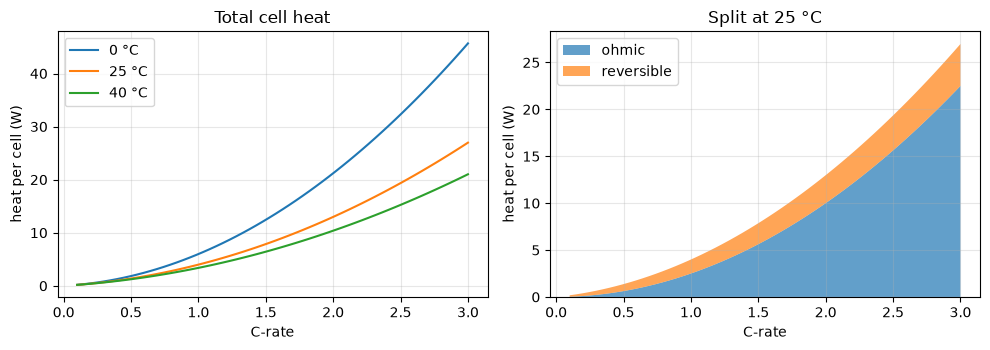

In [2]:
c = np.linspace(0.1, 3, 60)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for T_C in (0, 25, 40):
    o, r = q_cell(c, T_C)
    ax[0].plot(c, o + r, label=f'{T_C} °C')
ax[0].set(xlabel='C-rate', ylabel='heat per cell (W)', title='Total cell heat'); ax[0].legend(); ax[0].grid(alpha=.3)
o, r = q_cell(c, 25)
ax[1].stackplot(c, o, r, labels=['ohmic', 'reversible'], alpha=.7)
ax[1].set(xlabel='C-rate', ylabel='heat per cell (W)', title='Split at 25 °C'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [3]:
o1, r1 = q_cell(1.0, 25); o3, r3 = q_cell(3.0, 25)
print(f'At 1C, 25 °C: ohmic {o1:.2f} W, reversible {r1:.2f} W  -> reversible share {r1/(o1+r1):.0%}')
print(f'At 3C, 25 °C: ohmic {o3:.2f} W, reversible {r3:.2f} W  -> reversible share {r3/(o3+r3):.0%}')
print(f'Cold penalty at 2C: 0 °C makes {sum(q_cell(2,0)):.1f} W vs {sum(q_cell(2,25)):.1f} W at 25 °C')

At 1C, 25 °C: ohmic 2.50 W, reversible 1.49 W  -> reversible share 37%
At 3C, 25 °C: ohmic 22.50 W, reversible 4.47 W  -> reversible share 17%
Cold penalty at 2C: 0 °C makes 21.2 W vs 13.0 W at 25 °C


**Observation.** Ohmic heat grows with the square of current, so it takes over quickly as the C-rate rises.
The reversible part matters at low current. A cold cell makes noticeably more heat for the same current because its resistance is higher.

## 2. Heat from the pack

A pack of $N_s$ cells in series and $N_p$ in parallel carries the same C-rate in every cell, so

$$Q_{pack} = N_s\,N_p\,Q_{cell}$$

Pack: 96s3p of 50 Ah cells, about 53 kWh


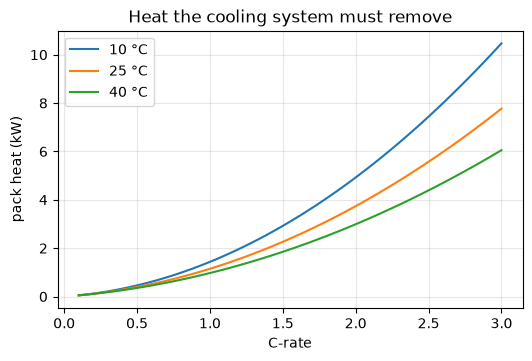

In [4]:
Ns, Np = 96, 3
pack_kWh = Ns * 3.7 * cap_Ah * Np / 1000
print(f'Pack: {Ns}s{Np}p of {cap_Ah:.0f} Ah cells, about {pack_kWh:.0f} kWh')

c = np.linspace(0.1, 3, 60)
Q_pack = {T: Ns*Np*np.sum(q_cell(c, T), axis=0) for T in (10, 25, 40)}
plt.figure(figsize=(6, 3.6))
for T, q in Q_pack.items():
    plt.plot(c, q/1000, label=f'{T} °C')
plt.xlabel('C-rate'); plt.ylabel('pack heat (kW)'); plt.title('Heat the cooling system must remove')
plt.legend(); plt.grid(alpha=.3); plt.show()

In [5]:
for cr in (1, 2, 3):
    print(f'{cr}C at 25 °C: {Ns*Np*sum(q_cell(cr, 25))/1000:.2f} kW of heat, for {cr*cap_Ah*Np*Ns*3.7/1000:.0f} kW electrical power')

1C at 25 °C: 1.15 kW of heat, for 53 kW electrical power
2C at 25 °C: 3.74 kW of heat, for 107 kW electrical power
3C at 25 °C: 7.77 kW of heat, for 160 kW electrical power


**Observation.** A few percent of the electrical power turns into heat, but at fast-charge rates that is several kilowatts
and the cooling loop is sized for it, not for the average drive.

## 3. Coolant flow

Energy balance on the coolant, where $\Delta T$ is the allowed temperature rise across the pack:

$$\dot m = \frac{Q}{c_p\,\Delta T}, \qquad \dot V = \frac{\dot m}{\rho}$$

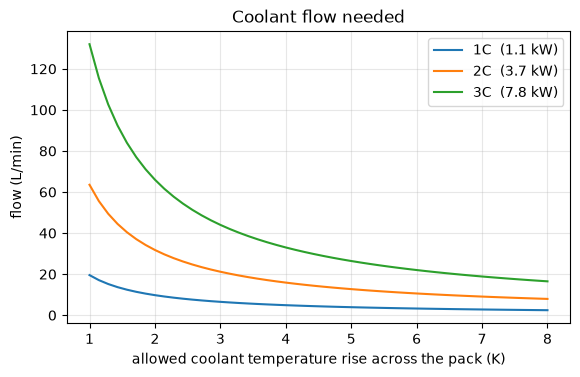

In [6]:
cp, rho = 3300.0, 1070.0          # 50/50 water-glycol, illustrative
dT = np.linspace(1, 8, 50)
plt.figure(figsize=(6.5, 3.8))
for cr in (1, 2, 3):
    Q = Ns*Np*sum(q_cell(cr, 25))
    Vdot = Q / (cp * dT) / rho * 1000 * 60      # L/min
    plt.plot(dT, Vdot, label=f'{cr}C  ({Q/1000:.1f} kW)')
plt.xlabel('allowed coolant temperature rise across the pack (K)'); plt.ylabel('flow (L/min)')
plt.title('Coolant flow needed'); plt.legend(); plt.grid(alpha=.3); plt.show()

In [7]:
Q2 = Ns*Np*sum(q_cell(2, 25))
for d in (2, 3, 5):
    print(f'2C, {d} K rise: {Q2/(cp*d)/rho*1000*60:.1f} L/min ({Q2/(cp*d):.2f} kg/s)')

2C, 2 K rise: 31.8 L/min (0.57 kg/s)
2C, 3 K rise: 21.2 L/min (0.38 kg/s)
2C, 5 K rise: 12.7 L/min (0.23 kg/s)


**Observation.** Halving the allowed temperature rise doubles the flow. A tighter rise across the pack means less temperature spread between
the first and last cell, but it costs pump power and pressure drop, which the next project looks at.
This calculation gives the first estimate only. The real flow is set by the pump curve and the branch hydraulics.

## 4. What if there is no cooling?

Adiabatic heating of the pack thermal mass, with $C_{th}=m\,c_{p,cell}$:

$$\frac{dT}{dt}=\frac{Q}{C_{th}}$$

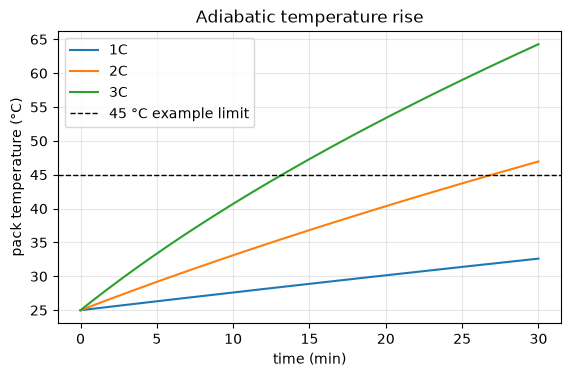

In [8]:
m_cell, cp_cell = 0.9, 1000.0          # kg, J/kgK (illustrative)
Cth = Ns*Np*m_cell*cp_cell
t = np.linspace(0, 30*60, 200)         # 30 minutes
plt.figure(figsize=(6.5, 3.8))
for cr in (1, 2, 3):
    T = 25.0 + 0.0*t
    # heat depends on temperature, so integrate step by step
    for i in range(1, len(t)):
        Q = Ns*Np*sum(q_cell(cr, T[i-1]))
        T[i] = T[i-1] + Q/Cth*(t[i]-t[i-1])
    plt.plot(t/60, T, label=f'{cr}C')
plt.axhline(45, color='k', ls='--', lw=1, label='45 °C example limit')
plt.xlabel('time (min)'); plt.ylabel('pack temperature (°C)'); plt.title('Adiabatic temperature rise')
plt.legend(); plt.grid(alpha=.3); plt.show()

In [9]:
print(f'Thermal mass of the pack: {Cth/1000:.0f} kJ/K')
for cr in (1, 2, 3):
    T = 25.0
    for k in range(30*60):
        T += Ns*Np*sum(q_cell(cr, T))/Cth
    print(f'{cr}C for 30 min, no cooling: {T:.1f} °C')

Thermal mass of the pack: 259 kJ/K
1C for 30 min, no cooling: 32.6 °C
2C for 30 min, no cooling: 47.0 °C


3C for 30 min, no cooling: 64.2 °C


**Observation.** At 1C the pack warms slowly. At 2C it reaches the 45 °C example limit in roughly half an hour, and at 3C much sooner.
This is why fast charging drives the cooling design.

**Limits of this notebook.** Lumped pack, constant coolant properties, no heat exchange with the surroundings,
one set of illustrative cell values. The numbers show how the quantities relate, not what a real pack does.